In [1]:
!pip install openpyxl matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Создаём данные для массива данных
np.random.seed(1)
n = 100
dates = pd.date_range(start='2050-01-01', periods=n, freq='D')
products =  np.random.choice(['Tablet', 'Camera', 'Phone', 'Microphone', 'Keyboard'], n)
prices = np.round(np.random.uniform(50.0,200.0, n), 2)
qts = np.random.randint(1,15, n)

# Создаём словарь который будет хранить даные которые мы создали
data = {
    "Date": dates, 
    "Product": products,
    'Price': prices,
    'Quantity': qts,
}
data

{'Date': DatetimeIndex(['2050-01-01', '2050-01-02', '2050-01-03', '2050-01-04',
                '2050-01-05', '2050-01-06', '2050-01-07', '2050-01-08',
                '2050-01-09', '2050-01-10', '2050-01-11', '2050-01-12',
                '2050-01-13', '2050-01-14', '2050-01-15', '2050-01-16',
                '2050-01-17', '2050-01-18', '2050-01-19', '2050-01-20',
                '2050-01-21', '2050-01-22', '2050-01-23', '2050-01-24',
                '2050-01-25', '2050-01-26', '2050-01-27', '2050-01-28',
                '2050-01-29', '2050-01-30', '2050-01-31', '2050-02-01',
                '2050-02-02', '2050-02-03', '2050-02-04', '2050-02-05',
                '2050-02-06', '2050-02-07', '2050-02-08', '2050-02-09',
                '2050-02-10', '2050-02-11', '2050-02-12', '2050-02-13',
                '2050-02-14', '2050-02-15', '2050-02-16', '2050-02-17',
                '2050-02-18', '2050-02-19', '2050-02-20', '2050-02-21',
                '2050-02-22', '2050-02-23', '2050-02-24'

In [4]:
# Cоздаём таблицу
df = pd.DataFrame(data)
df

,Date,Product,Price,Quantity
0,2050-01-01,Microphone,147.16,7
1,2050-01-02,Keyboard,103.09,10
2,2050-01-03,Tablet,164.48,7
3,2050-01-04,Camera,103.48,1
4,2050-01-05,Microphone,162.92,1
...,...,...,...,...
95,2050-04-06,Phone,119.32,8
96,2050-04-07,Tablet,69.84,7
97,2050-04-08,Phone,164.64,3
98,2050-04-09,Keyboard,81.91,11


In [5]:
df.head() # Смотрим первые 5 строк

,Date,Product,Price,Quantity
0,2050-01-01,Microphone,147.16,7
1,2050-01-02,Keyboard,103.09,10
2,2050-01-03,Tablet,164.48,7
3,2050-01-04,Camera,103.48,1
4,2050-01-05,Microphone,162.92,1


In [6]:
df.dtypes

Date        datetime64[us]
Product                str
Price              float64
Quantity             int32
dtype: object

In [7]:
#  Из нашего DataFrame делаем csv файл 
df.to_csv('random_sales.csv', index=False) 

In [8]:
# Из csv файла делаем DataFrame
df2 = pd.read_csv('random_sales.csv', parse_dates=['Date'])
df2

,Date,Product,Price,Quantity
0,2050-01-01,Microphone,147.16,7
1,2050-01-02,Keyboard,103.09,10
2,2050-01-03,Tablet,164.48,7
3,2050-01-04,Camera,103.48,1
4,2050-01-05,Microphone,162.92,1
...,...,...,...,...
95,2050-04-06,Phone,119.32,8
96,2050-04-07,Tablet,69.84,7
97,2050-04-08,Phone,164.64,3
98,2050-04-09,Keyboard,81.91,11


In [9]:
df.dtypes

Date        datetime64[us]
Product                str
Price              float64
Quantity             int32
dtype: object

In [10]:
df.to_excel('sales_data.xlsx')

In [11]:
df.to_json('sales_data.json', date_format='iso')

In [12]:
df.shape

(100, 4)

In [13]:
df.describe().round(2)

,Date,Price,Quantity
count,100,100.00,100.00
mean,2050-02-19 12:00:00,117.32,7.79
min,2050-01-01 00:00:00,51.35,1.00
25%,2050-01-25 18:00:00,81.13,5.00
50%,2050-02-19 12:00:00,114.10,8.00
75%,2050-03-16 06:00:00,161.21,11.25
max,2050-04-10 00:00:00,197.26,14.00
std,NaN,42.47,4.03


In [14]:
df.values[1:10]

array([[Timestamp('2050-01-02 00:00:00'), 'Keyboard', 103.09, 10],
       [Timestamp('2050-01-03 00:00:00'), 'Tablet', 164.48, 7],
       [Timestamp('2050-01-04 00:00:00'), 'Camera', 103.48, 1],
       [Timestamp('2050-01-05 00:00:00'), 'Microphone', 162.92, 1],
       [Timestamp('2050-01-06 00:00:00'), 'Tablet', 182.2, 3],
       [Timestamp('2050-01-07 00:00:00'), 'Tablet', 51.75, 13],
       [Timestamp('2050-01-08 00:00:00'), 'Camera', 124.72, 10],
       [Timestamp('2050-01-09 00:00:00'), 'Keyboard', 61.07, 7],
       [Timestamp('2050-01-10 00:00:00'), 'Keyboard', 168.04, 1]],
      dtype=object)

## Группировка строк

In [15]:
# Снчала группируем по строкам, 
# потом далее указываем какую функцию группировки выполнить для какой колонки
product_sales = df.groupby(['Product'])['Quantity'].sum().sort_values() # Метод groupby
product_sales

Product
Microphone    106
Phone         124
Keyboard      173
Camera        186
Tablet        190
Name: Quantity, dtype: int32

In [22]:
avarage_prices = df.groupby(['Product'])['Price'].mean().round(2) 
# Находим среднюю цену для каждого товара и округлили до 2
avarage_prices

Product
Camera        121.54
Keyboard      115.61
Microphone    129.43
Phone         123.47
Tablet        100.17
Name: Price, dtype: float64

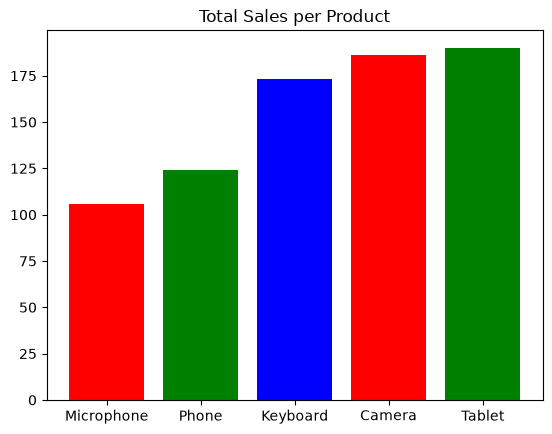

In [23]:
plt.bar(product_sales.index, product_sales.values, color=['red', 'green','blue'])
plt.title('Total Sales per Product')
amo = plt.show()
amo

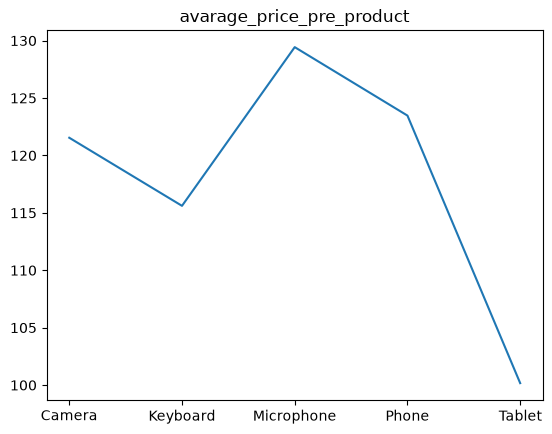

In [24]:
plt.plot(avarage_prices.index, avarage_prices.values)
plt.title('avarage_price_pre_product')
plt.show()

In [25]:
df3 = pd.read_csv('E:/python/notebooks/Pandas/random_sales.csv')
df3






,Date,Product,Price,Quantity
0,2050-01-01,Microphone,147.16,7
1,2050-01-02,Keyboard,103.09,10
2,2050-01-03,Tablet,164.48,7
3,2050-01-04,Camera,103.48,1
4,2050-01-05,Microphone,162.92,1
...,...,...,...,...
95,2050-04-06,Phone,119.32,8
96,2050-04-07,Tablet,69.84,7
97,2050-04-08,Phone,164.64,3
98,2050-04-09,Keyboard,81.91,11


In [64]:
n = 100
np.random.seed(10)
date = pd.date_range(start='2050-01-01', periods=n, freq='D')
cum_debt_overday = np.random.randint(1000000, 10000000, n)
cum_fpd = np.random.randint(50000,200000, n)


data = {
    'date': date,
    'debt': cum_debt_overday,
    'fpd_1': cum_fpd,
}

df = pd.DataFrame(data)
df

,date,debt,fpd_1
0,2050-01-01,8685385,102982
1,2050-01-02,9100989,100765
2,2050-01-03,6242852,72253
3,2050-01-04,4589440,178627
4,2050-01-05,7909297,94811
...,...,...,...
95,2050-04-06,9427942,101987
96,2050-04-07,2773152,159257
97,2050-04-08,2170499,89544
98,2050-04-09,3546783,171123


In [67]:
 df['debt_per_fpd'] = (df['fpd_1'] / df['debt']) * 100
 df2 = df['debt_per_fpd']
 df3 = pd.DataFrame(df['debt_per_fpd'])
 pd.concat([df, df3], axis=1)

,date,debt,fpd_1,debt_per_fpd,debt_per_fpd
0,2050-01-01,8685385,102982,1.185693,1.185693
1,2050-01-02,9100989,100765,1.107187,1.107187
2,2050-01-03,6242852,72253,1.157372,1.157372
3,2050-01-04,4589440,178627,3.892131,3.892131
4,2050-01-05,7909297,94811,1.198729,1.198729
...,...,...,...,...,...
95,2050-04-06,9427942,101987,1.081753,1.081753
96,2050-04-07,2773152,159257,5.742815,5.742815
97,2050-04-08,2170499,89544,4.125503,4.125503
98,2050-04-09,3546783,171123,4.824738,4.824738
